In [1]:
import serial
import serial.tools.list_ports
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import pandas as pd
plt.style.use('dark_background')

In [4]:
Ambit_Port = ""
Pulser_Port = ""
ports = serial.tools.list_ports.comports()
for port, desc, hwid in sorted(ports):
        if hwid[:4] == "USB ":
                print(f'Found USB devices:\t{hwid}')
                devices = hwid[4:].split(" ")
                if len(devices) > 1 and len(devices[0]) > 9:
                    if devices[0][-9:] == "1A86:55D4":
                        print(f'Ambit Likely at:\t{port}')
                        Ambit_Port = port
                    if devices[0][-9:] == "303A:1001":
                        print(f'Pulser Likely at:\t{port}')
                        Pulser_Port = port

if Ambit_Port == "": print(f'Ambit not Found')

if Pulser_Port == "": print(f'Pulser not Found')

Found USB devices:	USB VID:PID=303A:1001 SER=34:85:18:8E:88:FC LOCATION=1-4.2:x.0
Pulser Likely at:	COM14
Found USB devices:	USB VID:PID=1A86:55D4 SER=554C028876 LOCATION=1-4.1:x.0
Ambit Likely at:	COM23


In [5]:
def _readline(ser: serial.Serial, timeout: int):
    _t0 = time.time()
    s = ""
    while (time.time() - _t0 < timeout):
        if ser.in_waiting > 0:
            c = ser.read()
            if (c > bytes([0])) and (c < bytes([128])):
                if (c == b'\n') or (c == b'\r'):
                    if s == "":
                        pass
                    elif len(s) > 2:
                        return s
                else:
                    s += c.decode()
                
    return s

def _wait_for_line(ser: serial.Serial, target: str, input: str = "", timeout: float = 1.0, print_out = False):
    if input != "":
        ser.write((input + "\n").encode())
    t0 = time.time()
    timeout_t = t0 + timeout
    condition = False
    while (condition == False):
        _l = _readline(ser, 0.25)
        if target in _l:
            condition = True
        if print_out:
            if _l != "": print(_l)
        if time.time() > timeout_t:
            break

    return condition

    
def _parse_data_line(l:str)->dict:
    ret = {}
    if len(l) > 5:
        if (l[:2] == "T:") and ("," in l) and (":" in l):
            items = [n.split(':') for n in l.split(',') if ":" in n]
            for i in items:
                k = i[0]
                v = i[1]
                if len(k) > 0:
                    if v.isdecimal():
                        ret.update({k: int(v)})
                    if (v.count(".") == 1) and v.replace(".", "0").isdecimal():
                        ret.update({k: float(v)})

    return ret        


def Trigger(ser: serial.Serial) -> dict:
    ser.write(b"G")
    ser.flush()
    _ret = _parse_data_line(_readline(ser, .5))
    return _ret

def Ambit_actinic(ser: serial.Serial, v:int)->int:
    if (v > 255): return -1
    ser.write(bytes([65, v]))
    ser.flush()
    return v
    

def DAC_set(ser: serial.Serial, ch:int, v:int):
    ret = False
    if (ch == 2) or (ch == 4):
        if (v > -1) and (v < 4095):
            ret = _wait_for_line(ser, target = "Done", input = f'DAC,{ch},{v},\n', print_out=False)
    if ret == False: 
        print("DAC_set error", ch, v)
        return -1
    return v

def DAC_ONOFF(ser: serial.Serial, ch:int, onoff:bool):
    if onoff:
        if (ch == 2) or (ch == 4):
            _wait_for_line(ser, target = "Done", input = f'LED_ON,{ch},\n', print_out=False)
    else:
        if (ch == 2) or (ch == 4):
            _wait_for_line(ser, target = "Done", input = f'LED_OFF,{ch},\n', print_out=False)
        else:
            _wait_for_line(ser, target = "Done", input = f'LED_OFF,0,\n', print_out=False)

# plot autoscale
def autoscale(data: list, axis:plt.Axes):
    if len(data) == 0: return
    if len(data) == 1: 
        axis.set_ylim([data[0]-1, data[0]+1])
        return    
    l, h = axis.get_ylim()
    x, d = np.min(data), np.max(data)
    r = d - x

    _l, _h, a = l, h, False
    if (x < l) or (l < x - r):
        _l = x - 0.05 * r
        a = True
    if (d > h) or (h > l + r):
        _h = d + 0.05 * r
        a = True
    if a and _l != _h:
        axis.set_ylim([_l, _h])

def print_protocol(protocol:list)->None:
    _act_ambit, _act_blue, _act_red, act_blue, act_red = -1, -1, -1, 0, 0
    _timer = 0
    _blue_on_time, _red_on_time = 0, 0
    for _l in protocol:
        if _l[0] == 'M' and len(_l) == 4: # Run measurement        
            if (_act_ambit != _l[3]):   # Set ambit actinic
                if _l[3] > 4 and _l[3] < 255: 
                    _act_ambit = _l[3]
                else:
                    _act_ambit = 0
                #print(f'{_timer:<12.3f}Set Ambit Actinic to {_act_ambit}')
            if (_l[1] < 1): continue    # no data
            for _ in range(_l[1]):
                _timer += _l[2]
            print(f'{_timer:<12.3f}Meas {_l[1]}\t Interval: {_l[2]:.3f} sec \t Take {_l[1] * _l[2]:.2f} seconds\tAct:{_act_ambit:>3d}\tRed:{act_red:>3d}\tBlue:{act_blue:>3d}\t')

        if _l[0] == 'A' and len(_l) == 3: # Change Actinic
            if _l[1] == "B":
                if _l[2] > 0:
                    if _act_blue != _l[2]: 
                        _act_blue = _l[2]
                        if (_act_blue > 200 and act_blue < 200): _blue_on_time = _timer
                        print(f'{_timer:<12.3f}Set Blue Actinic: {_act_blue}')

                    print(f'{_timer:<12.3f}Blue Actinic ON')
                    act_blue = _act_blue
                else: 
                    print(f'{_timer:<12.3f}Blue Actinic OFF')
                    act_blue = 0

                
            if _l[1] == "R":
                if _l[2] > 0:
                    if _act_red != _l[2]: 
                        _act_red= _l[2]
                        if (_act_red > 200): _red_on_time = _timer
                        print(f'{_timer:<12.3f}Set Red Actinic: {_act_red}')
                    print(f'{_timer:<12.3f}Red Actinic ON')
                    act_red = _act_red
                else: 
                    print(f'{_timer:<12.3f}Red Actinic OFF')
                    act_red = 0

        if _l[0] == 'W' and len(_l) == 2:
            print(f'{_timer:<12.3f}Sleep for: {_l[1]} sec with \tAct:{_act_ambit:>3d}\tRed:{act_red:>3d}\tBlue:{act_blue:>3d}\t')
            _timer += _l[1]
        if _l[0] == 'P':
            print(f'{_timer:<12.3f}Update plot')




        if (act_blue > 200) and (_timer - _blue_on_time > 5): print(f'\t\t-------Blue Actinic @ {act_blue} for too long-------')
        if (act_red > 200) and (_timer - _red_on_time > 5): print(f'\t\t-------Red Actinic @ {act_red} for too long-------')
    return

### Protocol is a list of Lines
#### Each Line is a command to run, also a list ["Keyword", augments,,,,]


In [6]:
## "M": Measurement:
# ["M",   Number of points,   Interval in second, Ambit actinic 0-255]
# NOTE there are 3 Actinic light, one from Ambit and two from external controller (Blue)
# This command controls Actinic on Ambit, ideally for Saturation Flash. Intensity is ~ 3000uE @ 254. Depends on real working distance. 

Example_protocol = [
    ['M',     10,     0.1,    0],
    ['M',     250,     0.005,    254],
    ['M',     20,     0.01,    0]
    ]
print_protocol(Example_protocol)

1.000       Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red:  0	Blue:  0	
2.250       Meas 250	 Interval: 0.005 sec 	 Take 1.25 seconds	Act:254	Red:  0	Blue:  0	
2.450       Meas 20	 Interval: 0.010 sec 	 Take 0.20 seconds	Act:  0	Red:  0	Blue:  0	


In [5]:
## "A": External Actinic light:
# ["A",   "B" or "R",   Intensity (0 - 1000)]
# "B" = Blue LED
# "R" = Red LED
# The PAR is ~ Intensity x 10, you need to measure it in your setup
# !!!!NOTE: Due to hardware limitation, All LED should no be on for long time. 
# For Red and Blue External, Suggested limitations are:
# Intensity     |       Duration (s)
#   <50         |         No limit
#   50 - 100    |           <2min
#   100-200     |           <10s
#   200-500     |           < 2s
#   500+        |           <0.5s


Example_protocol = [
    ['M',     10,     0.1,    0],
    ['A',     "R",     50],
    ['M',     20,     1,    0],
    ['A',     "B",     50],
    ['M',     20,     1,    200],
    ['A',     "B",     0],
    ['M',     10,     0.1,    0],
    ['A',     "R",     0],
    ['M',     10,     0.1,    0]
    ]
print_protocol(Example_protocol)

1.000       Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red:  0	Blue:  0	
1.000       Set Red Actinic: 50
1.000       Red Actinic ON
21.000      Meas 20	 Interval: 1.000 sec 	 Take 20.00 seconds	Act:  0	Red: 50	Blue:  0	
21.000      Set Blue Actinic: 50
21.000      Blue Actinic ON
41.000      Meas 20	 Interval: 1.000 sec 	 Take 20.00 seconds	Act:200	Red: 50	Blue: 50	
41.000      Blue Actinic OFF
42.000      Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red: 50	Blue:  0	
42.000      Red Actinic OFF
43.000      Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red:  0	Blue:  0	


In [6]:
## "W": Wait:
# ["W",   Wait (seconds)] 
## "P": Update ploat:
# ["P"] 
# Update plot will take an unknown amount of time (100ms to 1s?), and protocol will pause during updating. Only update figure at non-timing-critical step. 

Example_protocol = [
    ['M',     10,     0.1,    0],
    ['A',     "R",     50],
    ['M',     20,     1,    0],
    ['A',     "B",     50],
    ['M',     20,     1,    200],
    ['P'],
    ['W', 10],
    ['A',     "R",     0],
    ['M',     10,     0.1,    0]
    ]
print_protocol(Example_protocol)


1.000       Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red:  0	Blue:  0	
1.000       Set Red Actinic: 50
1.000       Red Actinic ON
21.000      Meas 20	 Interval: 1.000 sec 	 Take 20.00 seconds	Act:  0	Red: 50	Blue:  0	
21.000      Set Blue Actinic: 50
21.000      Blue Actinic ON
41.000      Meas 20	 Interval: 1.000 sec 	 Take 20.00 seconds	Act:200	Red: 50	Blue: 50	
41.000      Update plot
41.000      Sleep for: 10 sec with 	Act:200	Red: 50	Blue: 50	
51.000      Red Actinic OFF
52.000      Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red:  0	Blue: 50	


In [7]:
# Here are some simple protocols for calibration and testing:

ambit_actinic_test = [['M',     5,     1,    250]] # Calibrate the real PAR using ambit actinic: 250 = 2400uE
Blue_actinic_test = [['A',     "B",     250],    ["W",   5]]   # Calibrate the real PAR using Blue LED: 250 = 2800uE
Red_actinic_test = [['A',     "R",     250],    ["W",   2]]   # Calibrate the real PAR using Red LED: 250 = 3200uE
signal_offset_protocol = [['M',     50,     .1,    0]] # Get_offset. Put no chlorophyll, measure the baseline, and substract if from latter measurements


In [10]:
## protocol blocks
# It might be easier to write protocols with small blocks
# Each block can be tested seperatedly and merge together

# e.g. Here's a saturation flash block
Sat_Flash = [    
    ['M',     10,     0.1,    0],
    ['M',     250,     0.005,    254],
    ['M',     20,     0.01,    0],
    ['M',     20,     0.1,    0]
    ]

# To merge it in a large protocol, use Python list append:
Protocol_Eg1 =  [
    ['M',     100,     .1,    0],
    *Sat_Flash,
    ['M',     100,     .1,    0]
    ]

print_protocol(Protocol_Eg1)

10.000      Meas 100	 Interval: 0.100 sec 	 Take 10.00 seconds	Act:  0	Red:  0	Blue:  0	
11.000      Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red:  0	Blue:  0	
12.250      Meas 250	 Interval: 0.005 sec 	 Take 1.25 seconds	Act:254	Red:  0	Blue:  0	
12.450      Meas 20	 Interval: 0.010 sec 	 Take 0.20 seconds	Act:  0	Red:  0	Blue:  0	
14.450      Meas 20	 Interval: 0.100 sec 	 Take 2.00 seconds	Act:  0	Red:  0	Blue:  0	
24.450      Meas 100	 Interval: 0.100 sec 	 Take 10.00 seconds	Act:  0	Red:  0	Blue:  0	


In [8]:
Sat_Flash = [    
    ['M',     10,     0.1,    0],
    ['M',     250,     0.005,    254],
    ['M',     20,     0.01,    0],
    ['M',     20,     0.1,    0]
    ]

Protocol_1 = [
    ['M',     60,     1,    0],
    *Sat_Flash,
    ['M',     10,     0.1,    0],
    ['A',     "B",    10],
    ['M',     20,     0.2,    0],
    ['P'],

    ['M',     60,     1,    0],

    *Sat_Flash,
    ['M',     10,     0.2,    0],
    ['P'],

    *Sat_Flash,
    ['M',     10,     0.2,    0],
    ['P'],

    *Sat_Flash,
    ['M',     10,     0.2,    0],
    ['P'],

    ['A',     "B",    0],
    ['M',     50,     0.2,    0],

    *Sat_Flash,
    ['M',     50,     0.2,    0],
    ['P'],

    *Sat_Flash,
    ['M',     50,     0.5,    0],
    ['P'],

    *Sat_Flash,
    ['M',     50,     1,    0],
    ['P'],
    
        
]

print_protocol(Protocol_1)

60.000      Meas 60	 Interval: 1.000 sec 	 Take 60.00 seconds	Act:  0	Red:  0	Blue:  0	
61.000      Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red:  0	Blue:  0	
62.250      Meas 250	 Interval: 0.005 sec 	 Take 1.25 seconds	Act:254	Red:  0	Blue:  0	
62.450      Meas 20	 Interval: 0.010 sec 	 Take 0.20 seconds	Act:  0	Red:  0	Blue:  0	
64.450      Meas 20	 Interval: 0.100 sec 	 Take 2.00 seconds	Act:  0	Red:  0	Blue:  0	
65.450      Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red:  0	Blue:  0	
65.450      Set Blue Actinic: 10
65.450      Blue Actinic ON
69.450      Meas 20	 Interval: 0.200 sec 	 Take 4.00 seconds	Act:  0	Red:  0	Blue: 10	
69.450      Update plot
129.450     Meas 60	 Interval: 1.000 sec 	 Take 60.00 seconds	Act:  0	Red:  0	Blue: 10	
130.450     Meas 10	 Interval: 0.100 sec 	 Take 1.00 seconds	Act:  0	Red:  0	Blue: 10	
131.700     Meas 250	 Interval: 0.005 sec 	 Take 1.25 seconds	Act:254	Red:  0	Blue: 10	
131.900     Meas 20	 Interval: 0.010 sec 

NEW Name Here Ready
Start
Run
Stop


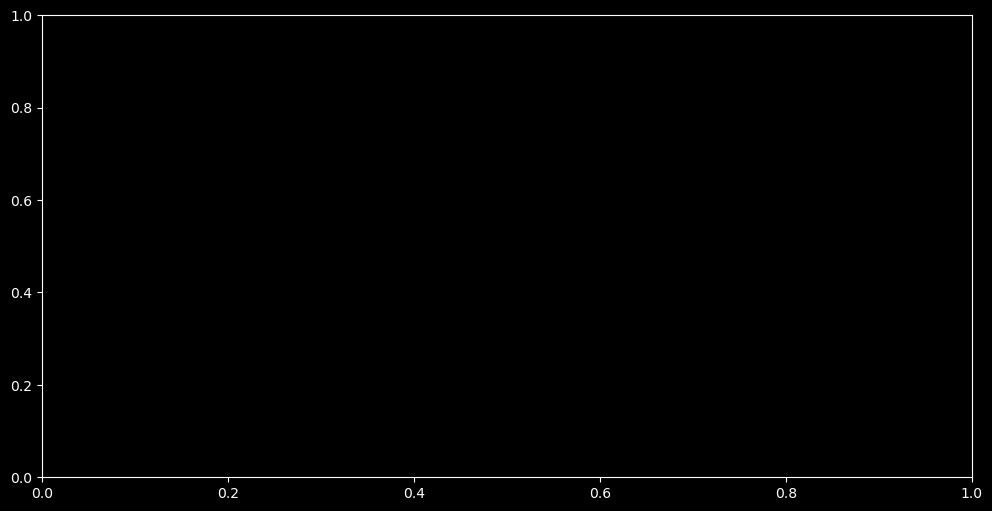

In [11]:
## This block run the protocol
# Change the protocol want to run:
run_protocol = Protocol_Eg1
# Signal offset when no exist
OFFSET = 4000
# Set the Serial ports for devices:
# If auto port detection doesn't work, put in Serial ports manually.

ser = serial.Serial(Ambit_Port, 115200, rtscts=False) # This is Ambit
try:
    ser_pulser = serial.Serial(Pulser_Port, 115200, dsrdtr= True, rtscts=False) # This is external LED
except:
    ser.close()
    raise ConnectionRefusedError
    





#
fig, axis = plt.subplots(1,1,figsize = (12,6))
START_TIME = time.time()
try:
    _wait_for_line(ser, target = "NEW Name", input = "hello", print_out=True)
    if not _wait_for_line(ser, target = "Start", input = "ww", print_out=True):
        ser.write(b'E\n')
        raise NameError("Function not started")
    
    if not _wait_for_line(ser, target = "Run", input = "", print_out=True):
        ser.write(b'E\n')
        raise NameError("Run not started")           


    _act_ambit, _act_blue, _act_red, act_blue, act_red = -1, -1, -1, 0, 0
    _data = []
    for _l in run_protocol:

        if _l[0] == 'M' and len(_l) == 4: # Run measurement
            
            if (_act_ambit != _l[3]):   # Set ambit actinic
                _act_ambit = Ambit_actinic(ser, _l[3])
            if (_l[1] < 1): continue    # no data
            for _ in range(_l[1]):
                _ts = time.perf_counter()
                _ret = Trigger(ser)
                if _ret != {}: 
                    _ret.update({"ACT":_act_ambit,"Blue":act_blue,"Red":act_red}.copy())
                    _data.append(_ret)
                _elapsed = time.perf_counter() - _ts
                if _elapsed < _l[2]: time.sleep(_l[2] - _elapsed)

        if _l[0] == 'A' and len(_l) == 3: # Change Actinic
            if _l[1] == "B":
                if _l[2] > 0:
                    if _act_blue != _l[2]: _act_blue = DAC_set(ser_pulser, 2, _l[2])
                    DAC_ONOFF(ser_pulser, 2, True)
                    act_blue = _act_blue
                else: 
                    DAC_ONOFF(ser_pulser, 2, False)
                    act_blue = 0
                
            if _l[1] == "R":
                if _l[2] > 0:
                    if _act_red != _l[2]: _act_red= DAC_set(ser_pulser, 4, _l[2])
                    DAC_ONOFF(ser_pulser, 4, True)
                    act_red = _act_red
                else: 
                    DAC_ONOFF(ser_pulser, 4, False)
                    act_red = 0
        

        if _l[0] == 'W' and len(_l) == 2:
            time.sleep(_l[1])

        if _l[0] == 'P':
            _plot_data = pd.DataFrame(_data)
            axis.clear()
            axis.plot(_plot_data['T']/1000, (_plot_data['S'] - OFFSET) / _plot_data['R'])
            display(fig)
            clear_output(True)
            


    

    DAC_ONOFF(ser_pulser, 0, False)
    Ambit_actinic(ser, 0)

    if not _wait_for_line(ser, target = "Stop", input = "E", print_out=True):
        ser.write(b'E\n')
        raise NameError("Run not Stopped")
    
finally:
    ser.close()
    ser_pulser.close()


data = pd.DataFrame(_data)
data.attrs['OFFSET'] = OFFSET
data.attrs['START_TIME'] = START_TIME
data.attrs['protocol'] = run_protocol

In [12]:
data.attrs

{'OFFSET': 4000,
 'START_TIME': 1738691730.8549724,
 'protocol': [['M', 100, 0.1, 0],
  ['M', 10, 0.1, 0],
  ['M', 250, 0.005, 254],
  ['M', 20, 0.01, 0],
  ['M', 20, 0.1, 0],
  ['M', 100, 0.1, 0]]}

In [14]:
data

,T,S,R,F,B,ACT,Blue,Red
0,5,7925,15539,2956,1549,0,0,0
1,103,8160,18395,1185,888,0,0,0
2,203,8189,19446,1043,868,0,0,0
3,304,8192,18595,1066,851,0,0,0
4,404,8205,18249,1081,842,0,0,0
...,...,...,...,...,...,...,...,...
492,24297,8479,18237,1523,836,0,0,0
493,24398,8489,18241,1444,836,0,0,0
494,24498,8466,18241,1365,832,0,0,0
495,24598,8486,18243,1373,840,0,0,0


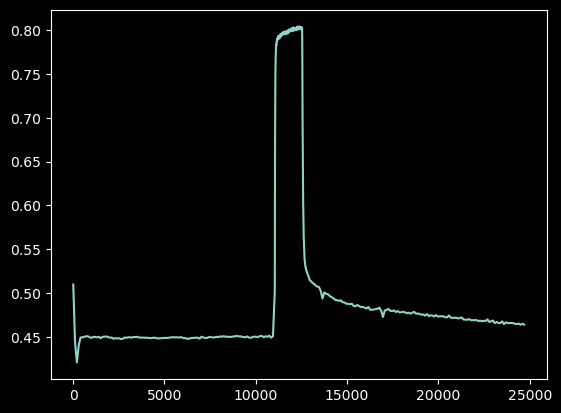

In [15]:
plt.plot(data['T'], data['S']/data['R'])